# **IPL Exploratory Data Analysis (2008-2024)**

## Final summary

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency
from wcwidth import width

In [37]:
df=pd.read_csv('matches.csv')
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

From df.info() we can see that method column has the most NaN values followed by city and we also have NaN values from player_of_match,result_margin,winner and both target_runs and target_overs

In [39]:
null_series = df.isnull().sum()
null_pct = (null_series / len(df) * 100).round(2)
null_pct

id                  0.00
season              0.00
city                4.66
date                0.00
match_type          0.00
player_of_match     0.46
venue               0.00
team1               0.00
team2               0.00
toss_winner         0.00
toss_decision       0.00
winner              0.46
result              0.00
result_margin       1.74
target_runs         0.27
target_overs        0.27
super_over          0.00
method             98.08
umpire1             0.00
umpire2             0.00
dtype: float64

Based on the above percentages method column has the most amount of NaNs that column is used to determine if the team won by dls or not here i will conver the NaN values to 'normal' instead of dropping the column and for the city column it would be best to fill the NaN with 'unknown'

For the remaining NaN values i would opt to just drop the columns as they have are relatively rare(<5%)

In [40]:
df['city']=df['city'].fillna('unknown')
df['method']=df['method'].fillna('normal')
df=df.dropna(axis=0,how='any')

In [41]:
null_series = df.isnull().sum()
null_pct = (null_series / len(df) * 100).round(2)
null_pct

id                 0.0
season             0.0
city               0.0
date               0.0
match_type         0.0
player_of_match    0.0
venue              0.0
team1              0.0
team2              0.0
toss_winner        0.0
toss_decision      0.0
winner             0.0
result             0.0
result_margin      0.0
target_runs        0.0
target_overs       0.0
super_over         0.0
method             0.0
umpire1            0.0
umpire2            0.0
dtype: float64

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1076.0,904242.821561,368624.123773,335982.0,548329.75,980960.0,1254065.25,1426312.0
result_margin,1076.0,17.259294,21.787444,1.0,6.00,8.0,20.00,146.0
target_runs,1076.0,165.794610,33.447489,43.0,146.00,166.0,187.00,288.0
target_overs,1076.0,19.769703,1.527598,5.0,20.00,20.0,20.00,20.0


Based on this we can clearly see that
1. The avg result margin 17.29 with standard deviation of 21.78 however the median is 8 with means that there is/are outliers affecting them which can further be seen by the difference between the 75% percentile and the max value which might indicate the outliers
2. Both the mean and median are almost the same in target_runs column implying that this is symmetrical however one thing to note is the minimum score of 43 is quite low for T20 and unusual perhaps DlS method was used
3. Ideally target overs should be 20 however due to rain the can be reduced and the above data shows that

In [43]:
name_map = {
    'Delhi Daredevils'           : 'Delhi Capitals',
    'Kings XI Punjab'            : 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants'    : 'Rising Pune Supergiant',
}
df['winner'] = df['winner'].replace(name_map)
df['team1']  = df['team1'].replace(name_map)
df['team2']  = df['team2'].replace(name_map)
df['team1'].value_counts()

team1
Royal Challengers Bengaluru    139
Chennai Super Kings            127
Punjab Kings                   123
Delhi Capitals                 123
Mumbai Indians                 121
Kolkata Knight Riders          117
Rajasthan Royals               100
Sunrisers Hyderabad             85
Deccan Chargers                 39
Pune Warriors                   23
Lucknow Super Giants            22
Gujarat Titans                  21
Gujarat Lions                   15
Rising Pune Supergiant          14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

Here just did a small change to merge teams that are same but had some minor name changes

In [44]:
total_wins=df['winner'].value_counts()
total_wins

winner
Mumbai Indians                 142
Chennai Super Kings            138
Kolkata Knight Riders          130
Royal Challengers Bengaluru    121
Delhi Capitals                 112
Rajasthan Royals               110
Punjab Kings                   109
Sunrisers Hyderabad             87
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

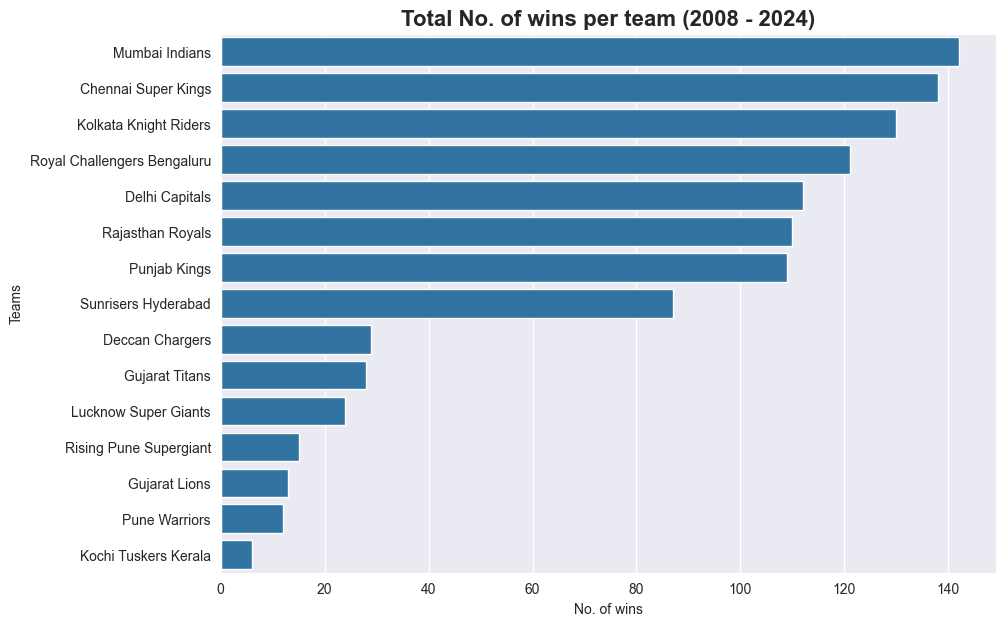

In [45]:
plt.figure(figsize=(10,7))
sns.barplot(total_wins,orient='h',)
plt.title('Total No. of wins per team (2008 - 2024)',fontsize=16, fontweight='bold')
plt.ylabel('Teams')
plt.xlabel('No. of wins')
plt.show()

So based on the above graph it is quite clear which teams have the most amount of wins.One thing to note that i particularly find interesting is the fact that the top 4 team ie MI,CSK,KKR and RCB which are the most fan favourite also have the most wins perhaps one of reason for this could be that due to the high number of wins people tend to like them more

#### In Ipl there is a common myth that as time went on most teams chose to field first so lets check on that

In [46]:


# Plotly Express treats countplots as histograms
fig = px.histogram(
    df,
    y="season",
    color="toss_decision",
    barmode="group",
    color_discrete_map={'bat': '#1f77b4', 'field': '#ff7f0e'}, # Custom colors
    title="Toss Decision Trends Across IPL Seasons",
    labels={"season": "IPL Season", "count": "Number of Matches"},
    height=600,
    width=1000
)

# Update layout to make it look incredibly clean
fig.update_layout(yaxis={'categoryorder':'category descending'})
fig.show()

from the graph we can cleary see that up until 2013 that there both the decisions were almost equal however after that only fielding was clearly preferred more than batting
now after finding this lets see if choosing field is actually beneficial